# Programming exercise 8: Entanglement and the transverse field Ising model

Due on Monday, 15.06.2026, 20h

In [ ]:
# load standard libraries

import numpy as np   # standard numerics library
import numpy.linalg as LA

import matplotlib.pyplot as plt   # for making plots

import time as time

import scipy.sparse.linalg as sLA

from ipywidgets import interactive, fixed
from ipywidgets import FloatSlider

from qutip import (tensor, basis) 

import Comp_Quant_Dynam as cqd

### Exercise 1: Building general spin 1/2 Hamiltonians

In the past exercises we have worked with the *collective* Ising model, where we could use the permutation symmetry to reduce the Hilbert space dimension from $2^N$ to $N+1$. This time we want to consider a model with nearest-neighbour spin interactions, the one-dimensional transverse-field Ising model (TFIM), where the permutation symmetry no longer holds. This model is analytically solvable (see e.g. https://www.sciencedirect.com/science/article/pii/0003491670902708). For the sake of learning how to build general spin models, we will solve it here by numerical means and compare the result to the exact solution as a check. The tools you develop here you can then apply to build any spin Hamiltonian straightforwardly. The Hamiltonian of the TFIM reads
$$
H=\sum_{i=0}^{N-1} -J\sigma_z^{(i)}\sigma_z^{(i+1)} - B \sigma_x^{(i)}
$$
where we want to use periodic boundary conditions, i.e. the $N$th spin is identified with the $0$th spin.

To solve it we first set up a framework for general spin 1/2 models.
We will work in the canonical product basis of states $|i_0,...,i_{N-1}\rangle$, where $i_k \in {0,1}$. This basis of course has the problem of exponential scaling of the number of basis states with particle number N. But we still want to use it to keep our approach as general as possible, which then just allows us to use up to 12 or so spins with reasonable computation time.

The recipe for constructing general spin models is the following:

1) Define the single-spin operators $s_x$, $s_y$, $s_z$, and the 2x2 identity, $\mathbb{1}$ as sparse matrices (csr_matrix should work best).

2) Build a list of all single-spin operators acting on spin $i=0...N-1$ in the $N$-spin Hilbert space.
$$
s_\alpha^{(i)} = \mathbb{1}^{\otimes i}\otimes s_\alpha \otimes \mathbb{1}^{\otimes (N-i-1)}
$$
where $\alpha \in \{x,y,z\}$. Use the Kronecker product for sparse matrices to do this. (Make sure you understand how the indexing/ordering of the matrix elements is done by `kron()`!)

3) Construct the Hamiltonian (or any other Hermitian operator) by adding up its individual terms, using the dot product for interaction terms. Remember that the Hamiltonian was defined with Pauli operators, not spin operators, which differ by a factor of two. (Alternatively, you could build all the Pauli operators in the $N$-particle Hilbert space instead of the spin operators.)

Test your implementation by calculating the ground state energy of the transverse field Ising model and comparing it to the analytical result (for even $N$)
$$
E_0^{analyt} = -\sum_{k=-(N-1)/2}^{(N-1)/2}\sqrt{1+B^2 + 2B\cos(2\pi k/N)}
$$
where the $J=1$ was chosen without loss of generality.

Calculate a few low lying eigenpairs for $N=10$ and a grid of $B$-values between 0 and 2 and plot the numerical and analytical result for the ground state energy. Keep in mind that compared to the reference given above, there might be factors of two differences since they define the Hamiltonian with spin operators instead of Pauli operators.

Also think about what the ground state should be at large $B$ and at $B=0$.

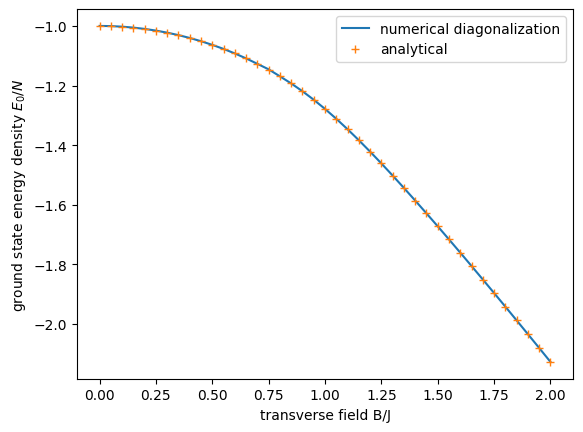

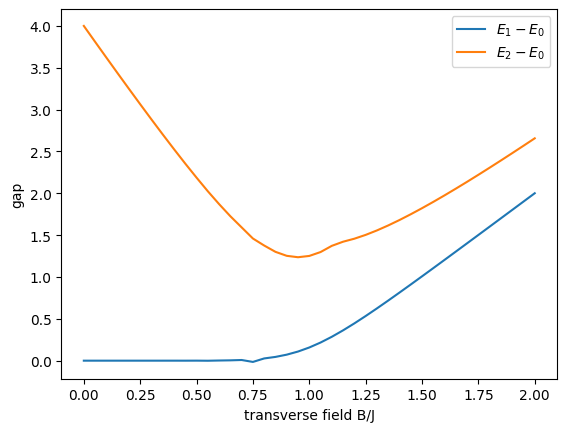

In [2]:
N = 10
sxis, syis, szis = cqd.operators.build_single_spin_ops_sparse(N)
    
# calculate the ground state and compare to analytical result
Bvec = np.linspace(0, 2, 41)
result = np.zeros((len(Bvec), 4))

for i in range(len(Bvec)):
    H_mat = cqd.hamiltonians.build_H_TFIM_individual(N, Bvec[i])
    result[i, :3], evecs = sLA.eigsh(H_mat, k=3, which='SA') # numerical ground state energy
    result[i,3] = cqd.hamiltonians.E_TFIM_individual_exact(N, Bvec[i]) # analytical ground state energy

plt.plot(Bvec, result[:, 0] / N)
plt.plot(Bvec, result[:, 3] / N, '+')
plt.legend(['numerical diagonalization','analytical'])
plt.xlabel('transverse field B/J')
plt.ylabel('ground state energy density $E_0/N$')
plt.show()

plt.plot(Bvec, result[:, 1] - result[:, 0])
plt.plot(Bvec, result[:, 2] - result[:, 0])
plt.legend(['$E_1-E_0$','$E_2-E_0$'])
plt.xlabel('transverse field B/J')
plt.ylabel('gap')
plt.show()

### Exercise 2: Taking partial traces

The TFIM has a quantum phase transition at $B/J=1$ from a ferromagnetic to a paramagnetic phase. You can use your code from exercise 1 to see that the gap is minimal around this value. Note that the model also has the $Z_2$ symmetry (invariance under flipping of all spins) which we saw in the collective Ising model, so you would look at the gap of ground and second excited state.
At the phase transition point (or quantum critical point), long-range correlations emerge in the ground state. An interesting feature is also that at the quantum critical point the half-chain entanglement entropy diverges logarithmically as $N$ goes to infinity (see for example https://arxiv.org/abs/0803.3610 Fig. 3). For finite $N$ we should already see that the entanglement entropy becomes maximal approximately at the quantum critical point.

To calculate the half-chain entanglement entropy in the ground state of the transverse Ising chain, you should proceed as follows:

1) Calculate the partial trace over $N/2$ spins. The matrix element of the reduced density of a state $|\psi\rangle = \sum_i c_i |i\rangle$ (where $|i\rangle$ are the $N$-spin basis states) can be expressed as
$$
(\rho_{red,N/2})_{ij} = \sum_{k=0}^{2^{N/2}-1} c_{i+k*2^{N/2}}c^*_{j+k*2^{N/2}}
$$
(This might look different depending on how the states are ordered in your basis.)

2) Calculate the eigenvalues $p_i$ of $\rho_{red,N/2}$, sort them from largest to smallest. This is the entanglement spectrum. The rank of $\rho_{red,N/2}$ is called entanglement dimension (or Schmidt rank). For a separable state the entanglement dimension is 1, i.e. only one eigenvalue is non-zero. (Note that in the lecture we defined the eigenvalues as $\lambda_i$.)

3) Calculate the von-Neumann entanglement entropy $S_E = -\sum_i p_i \log(p_i)$. Consider that some of the eigenvalues can be zero. Due to the finite numerical precision they can even turn negative. These you want to exclude from the sum. (Since $\lim_{p\rightarrow 0} p\log(p) =0$ we are not modifying the outcome significantly by neglecting small p's.)

Test your code for some cases where you know the answer, for example a separable state or a Bell pair state of 2 qubits. The qutip library also has the capability of calculating partial traces. If you are interested you can compare to this for testing.

Then calculate the entanglement spectrum and entropy for the same parameter scan as in exercise 1. Document your observations.

Optional: Try to see to how large $N$ you can push the numerics. Observe the $N$-scaling of ground state entanglement at the critical point.

Optional: Calculate the Schmidt coefficients using the singular value decomposition. This should actually be technically easier than calculating partial traces (see lecture notes).

In [3]:
# # note that my convention is that the basis states are ordered as {|0...00>,|0...01>,|0...010> etc}

# def partial_trace(psi, M): # M = number of spins to be traced over (assumed to be spins N-M+1 to N)
#     dim = len(psi)
#     dim_red = 2 ** (N - M)
#     dim_trace = 2 ** M
#     rho_red = np.zeros((dim_red, dim_red), dtype=complex)
#     for i in range(dim_red):
#         for j in range(i, dim_red):
#             rho_red[i,j] = psi[range(i * dim_trace, (i + 1) * dim_trace)].T @ psi[range(j * dim_trace, (j + 1) * dim_trace)].conj()
#     rho_red = rho_red + rho_red.T.conj() - np.diag(np.diag(rho_red)) # make it Hermitian
#     return rho_red

# # entanglement spectrum
# def get_evals(rho):
#     evals, evecs = LA.eigh(rho)
#     return np.flip(evals) # eigh returns eigenvalues sorted in ascending order, so need to reverse list

# # von Neumann entanglement entropy
# def entanglement_entropy(rho):
#     ps = get_evals(rho)
#     ps = ps[np.nonzero(np.around(ps, 10))]
#     return -np.sum(ps * np.log2(ps))

In [4]:
# testing for product states and for Bell states
N = 2
print('Product State')
Psi=np.kron([0,1],[1,0])
print(f"Psi = {Psi}")
rhoRed = cqd.utility.partial_trace(Psi, 1) # trace over the last spin
print("Reduced density matrix:")
print(rhoRed)
ps = cqd.utility.get_evals(rhoRed)
print(f"Entanglement spectrum: {ps}")
print(f"Von Neumann entropy: {cqd.utility.entanglement_entropy(rhoRed)}")

print('Bell State')
Psi=(np.kron([0,1], [0,1])+np.kron([1,0], [1,0]))/np.sqrt(2) # psi is a column vector
print(f"Psi = {Psi}")
rhoRed = cqd.utility.partial_trace(Psi, 1) # trace over the last spin
print("Reduced density matrix:")
print(rhoRed)
ps = cqd.utility.get_evals(rhoRed)
print(f"Entanglement spectrum: {ps}")
print(f"Von Neumann entropy: {cqd.utility.entanglement_entropy(rhoRed)}")



Product State
Psi = [0 0 1 0]
Reduced density matrix:
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Entanglement spectrum: [1. 0.]
Von Neumann entropy: -0.0
Bell State
Psi = [0.70710678 0.         0.         0.70710678]
Reduced density matrix:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Entanglement spectrum: [0.5 0.5]
Von Neumann entropy: 1.0


In [5]:
# testing for 3 qubit states, comparing to qutip
# Note: I get agreement with qutip if I compare tracing over the lasst M spins in my code
# to tracing over the first M spins in qutip. I interpret this as qutip assuming the 
# reverse ordering of the basis states.

N = 3
dim = 2 ** N
Psi = (np.eye(1, dim, 0)[0]+ np.eye(1, dim, dim - 2)[0]) / np.sqrt(2) # psi is a column vector
print(f"Psi = {Psi}")

rhoRed = cqd.utility.partial_trace(Psi, 1) # trace over the last spin
print("Reduced density matrix:")
print(rhoRed)

ps = cqd.utility.get_evals(rhoRed)
print(f"Entanglement spectrum: {ps}")
print(f"Von Neumann entropy: {cqd.utility.entanglement_entropy(rhoRed)}", "\n")

# using qutip
psi = (tensor(basis(2, 0), basis(2, 0), basis(2, 0)) + tensor(basis(2, 1), basis(2, 1), basis(2, 0))) / np.sqrt(2)
print(f"Psi = {psi}")
print(f"Reduced density matrix: {psi.ptrace([0, 1])}") # argument: vector of spins that should be kept (last spin has index 2)

Psi = [0.70710678 0.         0.         0.         0.         0.
 0.70710678 0.        ]
Reduced density matrix:
[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]
Entanglement spectrum: [1. 0. 0. 0.]
Von Neumann entropy: 3.2034265038149176e-16 

Psi = Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.70710678]
 [0.        ]]
Reduced density matrix: Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]


In [19]:
# apply to calculate ground state of Ising model
N = 12

sxis, syis, szis = cqd.operators.build_single_spin_ops_sparse(N)

# calculate the ground state and its entanglement specturm and half chain entanglement entropy
Bvec = np.linspace(0, 2, 41)
SvN_all = np.zeros((len(Bvec)))
Ent_spec_all = np.zeros((len(Bvec),int(2 ** (N / 2))))
Sx_all = np.zeros((len(Bvec)))
Sz_all = np.zeros((len(Bvec)))
for i in range(len(Bvec)):
    Hmat = cqd.hamiltonians.build_H_TFIM_individual(N, Bvec[i])
    E0, evecs = sLA.eigsh(Hmat, k=1, which='SA') # numerical ground state
    gs = evecs[:, 0]
    rho_red = cqd.utility.partial_trace(gs, int(N / 2))
    Ent_spec_all[i] = cqd.utility.get_evals(rho_red)
    SvN_all[i] = cqd.utility.entanglement_entropy(rho_red)
    # spins expectation values: Due to translation invariance, we can look at any single spin (here the first)
    Sx_all[i] = np.real(cqd.utility.expectation_value(gs, sxis[0]))
    Sz_all[i] = np.real(cqd.utility.expectation_value(gs, szis[0]))

In [20]:
SvN_all

array([0.16591601, 0.98719834, 1.00001758, 1.00008235, 1.00024308,
       1.0005646 , 1.00112971, 1.00204398, 1.00344317, 1.00550464,
       1.00846351, 1.01263132, 1.01840609, 1.02624267, 1.03651077,
       1.04910519, 1.06263699, 1.07322794, 1.07373922, 1.05544261,
       1.0131391 , 0.9497303 , 0.8746267 , 0.79781826, 0.72586691,
       0.66159995, 0.60545461, 0.55675641, 0.51447775, 0.47758935,
       0.44518868, 0.416527  , 0.39099725, 0.36811082, 0.34747395,
       0.32876754, 0.31173097, 0.29614954, 0.28184476, 0.26866698,
       0.25648964])

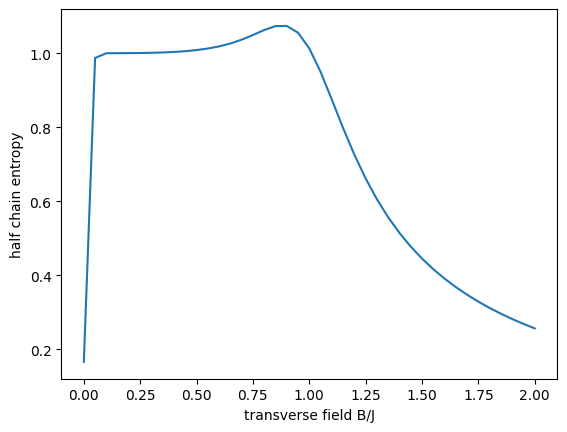

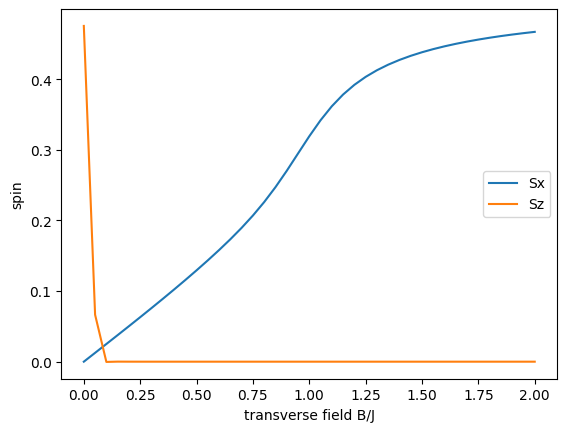

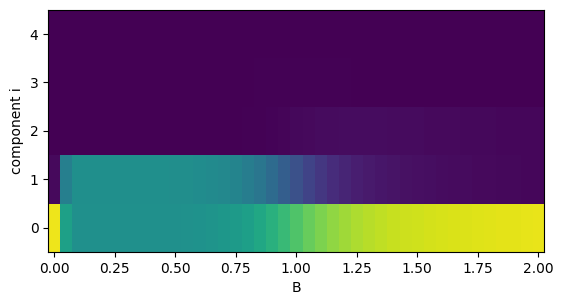

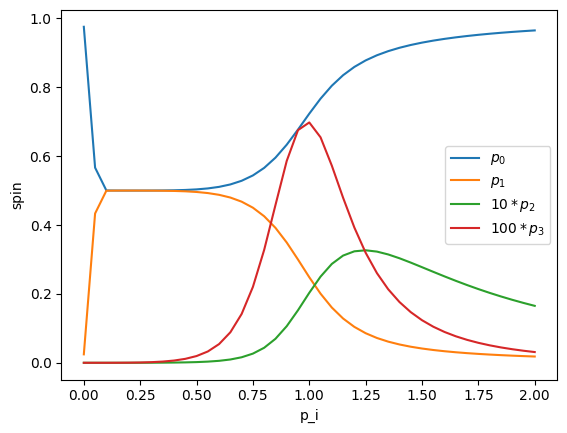

In [21]:
plt.plot(Bvec,SvN_all)
# plt.legend(['numerical diagonalization','analytical'])
plt.xlabel('transverse field B/J')
plt.ylabel('half chain entropy')
plt.show()

plt.plot(Bvec,Sx_all)
plt.plot(Bvec,Sz_all)
plt.legend(['Sx','Sz'])
plt.xlabel('transverse field B/J')
plt.ylabel('spin')
plt.show()

dB=Bvec[1]-Bvec[0]
iTo = 5
extent = (Bvec[0] - dB / 2, Bvec[-1] + dB / 2, 0 - 0.5, 5 - 0.5)
plt.imshow(np.flip(Ent_spec_all[:,:5], axis=1).T, extent=extent, vmax=1, aspect=.2)
plt.xlabel('B')
plt.ylabel('component i')
plt.show()

plt.plot(Bvec, Ent_spec_all[:, 0])
plt.plot(Bvec, Ent_spec_all[:, 1])
plt.plot(Bvec, 10*Ent_spec_all[:, 2])
plt.plot(Bvec, 100*Ent_spec_all[:, 3])
# plt.plot(Bvec,1000*Ent_spec_all[:,4])
plt.xlabel('p_i')
plt.ylabel('spin')
plt.legend(['$p_0$','$p_1$','$10*p_2$','$100*p_3$'])
plt.show()

One can see the numerical instability due to the degeneracy of the ground state as we had it in the collective case.

As expected, the entanglement entropy is peaked at the critical point and one sees that higher Schmidt numbers build up there.

The limits are as expected:  At large field, the ground state is a product state $|++...+\rangle$ and thus zero entanglement entropy, and at low field it is a cat state $(|00...0\rangle+|11...1\rangle)/\sqrt(2)$, which has $p_0=p_1=1/2$ and thus $S_E=\log(2)$.

### Optional Exercise 3: Time-dependence of entanglement entropy

Calculate the time-evolution for all spins being in the state $|+\rangle = (|0\rangle+|1\rangle)/\sqrt{2}$ initially.

If you evolve this state with the quantum critical Ising Hamiltonian, the entanglement entropy should increase very rapidly in time and saturate due to the finite system size. The saturation value is extensive in system size (volume law). This makes simulating the time evolution for quenches near the critical point challenging for techniques based on matrix product states (next lecture).

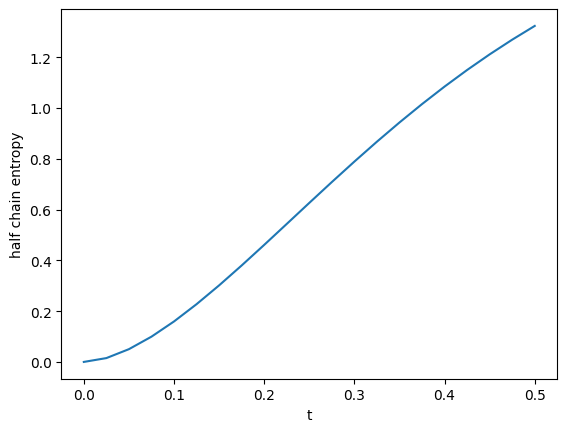

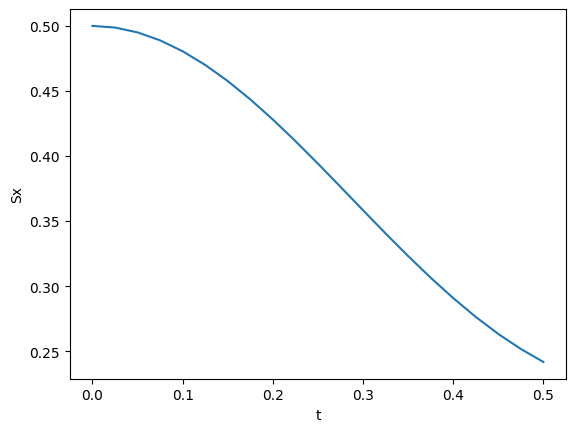

In [9]:
N = 10
dim = 2 ** N
tvec = np.linspace(0, .5 , 21)
ini = np.full(dim, 1 / np.sqrt(dim)) # all along x

sxis, syis, szis = cqd.operators.build_single_spin_ops_sparse(N)

ome = 1
Hmat = cqd.hamiltonians.build_H_TFIM_individual(N, ome)
evals, evecs = LA.eigh(Hmat.toarray()) # full diagonalization
iniProj = cqd.unitaries.init_coeffs_eigenbasis(ini, evecs)

Sx_table2 = np.zeros((len(tvec)), dtype=complex)
SvN_all = np.zeros((len(tvec)))
Ent_spec_all = np.zeros((len(Bvec), int(2 ** (N / 2))))
for it in range(len(tvec)):
    Psit = cqd.unitaries.t_evol_eigenbasis(iniProj, tvec[it], evals, evecs)
    Sx_table2[it] = cqd.utility.expectation_value(Psit, sxis[0])
    rhoRed = cqd.utility.partial_trace(Psit, int(N / 2))
    Ent_spec_all[it] = cqd.utility.get_evals(rhoRed)
    SvN_all[it] = cqd.utility.entanglement_entropy(rhoRed)

plt.plot(tvec, SvN_all)
# plt.legend(['numerical diagonalization','analytical'])
plt.xlabel('t')
plt.ylabel('half chain entropy')
plt.show()

plt.plot(tvec, np.real(Sx_table2))
# plt.legend(['numerical diagonalization','analytical'])
plt.xlabel('t')
plt.ylabel('Sx')
plt.show()

### Optional Exercise 4: Spin squeezing and entanglement

Let us look at the *collective* Ising spin-model with a transverse field one last time. The Hamiltonian is still
$$
H=-\frac{J}{N}S_z^2 - \Omega S_x
$$
with the collective spin operators $S_\alpha = \sum_i \sigma_i^\alpha/2$, where $\sigma_i^\alpha$ is a Pauli operator acting on spin $i$. This time we want to examine how spin squeezed states form under the dynamics of this model. All we have to do is to initialize the system with all spins pointing along the x-direction, i.e. in the coherent spin state $|CSS(\pi/2,0)\rangle$. For any small value of $\Omega$ (we can actually choose $\Omega=0$) we will observe spin squeezing.

Plot the Husimi distribution of the state using the "front view" from programming exercise 7 and observe how it evolves with time. Evaluate $S_x$ and the variance in any direction perpendicular to $S_x$ by rotating the state about the x-axis and calculating the variance of $S_z$ to determine the direction of maximal squeezing.

Calculate the optimal squeezing parameter $\min_{\mathbf{n}_\perp} = N (\Delta (\mathbf{n}_\perp\cdot \mathbf{S}))^2/\langle S_x\rangle^2$ as a function of time. Why does it increase again after some time?

Spin squeezing is associated with the buildup of entanglement. Calculate the entanglement entropy for the above time evolution. You can use the techniques from exercises 1 and 2 for this and solve the collective Ising model in the product basis, which of course allows you only to go to small numbers of spins, but the effects will still be visible. Note that one can also calculate the reduced density using symmetrized Dicke states (see https://arxiv.org/abs/cond-mat/0409611). You can implement this as a cross check and for going to larger N.

In [ ]:
N = 40
theta = np.pi / 2
phi = 0
psi0 = cqd.utility.CSS(N, theta, phi)

ome = 0
H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)
evals, evecs = LA.eigh(H_mat.toarray()) # full diagonalization

print("H = ", H_mat.tocsc())

def f(t, state, evals, evecs):
    N = len(state) - 1
    init_proj = cqd.unitaries.init_coeffs_eigenbasis(state, evecs)
    Psit = cqd.unitaries.t_evol_eigenbasis(init_proj, t, evals, evecs)
    zvec, yvec, Hdistr = cqd.utility.Husimi_front(N, Psit, 50, 50)
    plt.imshow(Hdistr, extent=(-1, 1, -1, 1), aspect=1)
    plt.contourf(zvec, yvec, Hdistr, 10, vmax=0.5)#
    plt.title("front view")
    plt.xlabel('y')
    plt.ylabel('z')

H =  <Compressed Sparse Column sparse array of dtype 'float64'
	with 40 stored elements and shape (41, 41)>
  Coords	Values
  (0, 0)	-10.0
  (1, 1)	-9.025
  (2, 2)	-8.1
  (3, 3)	-7.2250000000000005
  (4, 4)	-6.4
  (5, 5)	-5.625
  (6, 6)	-4.9
  (7, 7)	-4.2250000000000005
  (8, 8)	-3.6
  (9, 9)	-3.0250000000000004
  (10, 10)	-2.5
  (11, 11)	-2.025
  (12, 12)	-1.6
  (13, 13)	-1.225
  (14, 14)	-0.9
  (15, 15)	-0.625
  (16, 16)	-0.4
  (17, 17)	-0.225
  (18, 18)	-0.1
  (19, 19)	-0.025
  (21, 21)	-0.025
  (22, 22)	-0.1
  (23, 23)	-0.225
  (24, 24)	-0.4
  (25, 25)	-0.625
  (26, 26)	-0.9
  (27, 27)	-1.225
  (28, 28)	-1.6
  (29, 29)	-2.025
  (30, 30)	-2.5
  (31, 31)	-3.0250000000000004
  (32, 32)	-3.6
  (33, 33)	-4.2250000000000005
  (34, 34)	-4.9
  (35, 35)	-5.625
  (36, 36)	-6.4
  (37, 37)	-7.2250000000000005
  (38, 38)	-8.1
  (39, 39)	-9.025
  (40, 40)	-10.0


In [11]:
interactive(f, t=FloatSlider(min=0,max=10,step=0.5), state=fixed(psi0), evals=fixed(evals), evecs=fixed(evecs))

interactive(children=(FloatSlider(value=0.0, description='t', max=10.0, step=0.5), Output()), _dom_classes=('w…

In [13]:
N = 10
theta = np.pi/2
phi = 0
psi0 = cqd.utility.CSS(N, theta, phi)

ome = 0.0
H_mat = cqd.hamiltonians.build_H_TFIM(N, ome).tocsc()

Sx, Sy, Sz = cqd.operators.build_spin_ops_sparse(N)

tvec = np.linspace(0, 4, 21)
angles = np.linspace(0, np.pi/4, 50, endpoint=False)
rot_mat_arr = np.zeros((len(angles), N + 1, N + 1), dtype=complex)

for j in range(len(angles)):
    rot_mat_arr[j, :, :] = sLA.expm(-1j * angles[j] * Sx).toarray()
    
Sx_table = np.zeros((len(tvec)), dtype=complex)
var_table = np.zeros((len(tvec),len(angles)), dtype=complex)
Ent_spec_all_coll = np.zeros((len(tvec),int(N/2)+1), dtype=complex)
SvN_all_coll = np.zeros((len(tvec)), dtype=complex)

for it in range(len(tvec)):
    psit =  sLA.expm(-1j * tvec[it] * H_mat) @ psi0
    Sx_val = cqd.utility.expectation_value(psit, Sx)
    #print(Sxval)
    Sx_table[it] = Sx_val
    rho_red = cqd.utility.trace_half_collective(psit)
    #print(rhoRed[:2,:2])
    Ent_spec_all_coll[it] = cqd.utility.get_evals(rho_red)
    SvN_all_coll[it] = cqd.utility.entanglement_entropy(rho_red)
    for j in range(len(angles)):
        Sz2 = Sz @ Sz
        psi_rot = rot_mat_arr[j] @ psit
        var_Sz = cqd.utility.expectation_value(psi_rot, Sz2) - (cqd.utility.expectation_value(psi_rot, Sz)) ** 2
        var_table[it,j] = var_Sz
    



/home/niklas/PhD/Code/Venvs/cqd/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/home/niklas/PhD/Code/Venvs/cqd/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/niklas/PhD/Code/Venvs/cqd/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csc_array is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


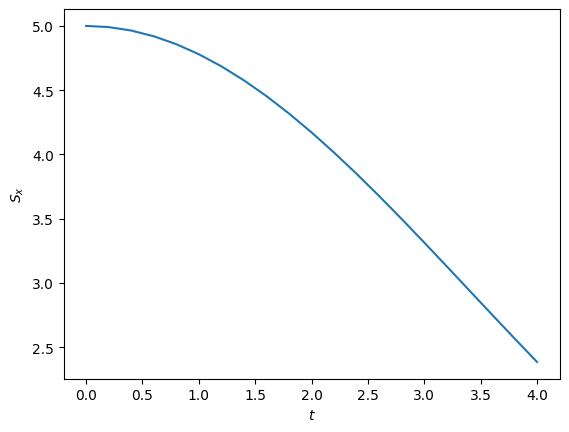

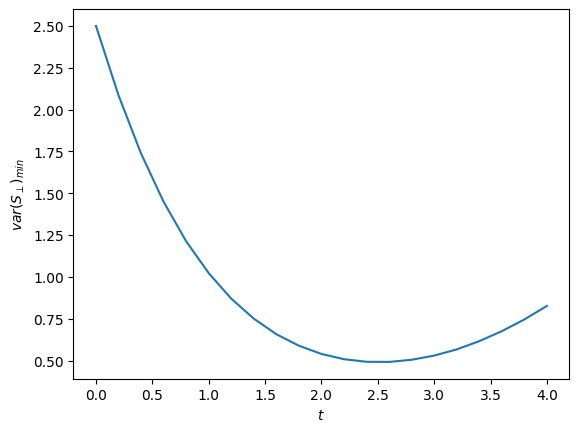

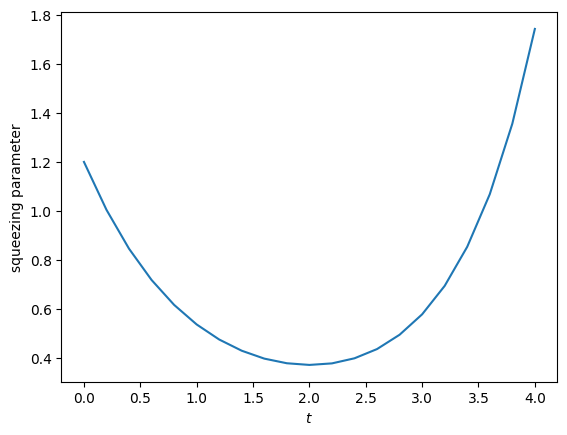

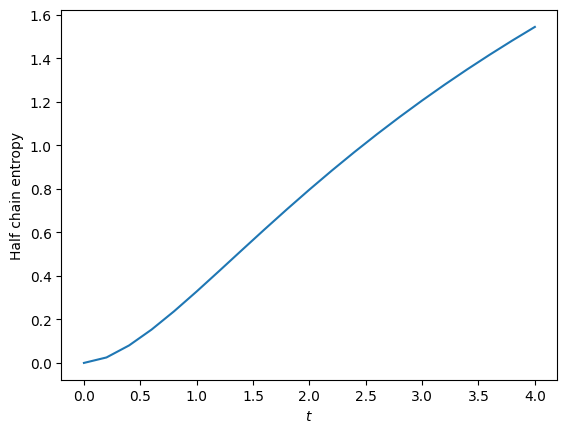

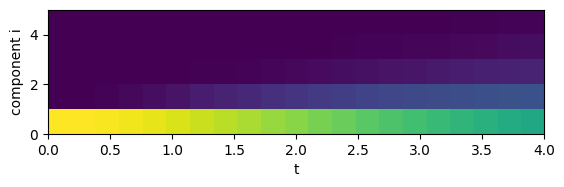

In [24]:
plt.plot(tvec, np.real(Sx_table))
plt.xlabel('$t$')
plt.ylabel('$S_x$')
plt.show()
plt.plot(tvec, np.real(np.amin(var_table, axis=1)))
plt.xlabel('$t$')
plt.ylabel('$var(S_\\perp)_{min}$')
plt.show()
plt.plot(tvec, (N * np.real(np.amin(var_table, axis=1) / Sx_table ** 2)))
#plt.yscale('log')
plt.xlabel('$t$')
plt.ylabel('squeezing parameter')
plt.show()

plt.plot(tvec, np.real(SvN_all_coll))
plt.xlabel('$t$')
plt.ylabel('Half chain entropy')
plt.show()

plt.imshow(np.real(np.flip(Ent_spec_all_coll[:,:5], axis=1).T), extent=(tvec[0], tvec[-1], 0, 5), vmax=1,aspect=.2)
plt.xlabel('t')
plt.ylabel('component i')
plt.show()